In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *

In [3]:
import os
import sys
sys.path.append(os.path.abspath("conditional-flow-matching"))
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

In [4]:
import random
import umap
from models.modules import *

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
from scripts.run_model import *

In [7]:
%reload_ext autoreload
%autoreload 2

In [8]:
############################################################

In [9]:
from torchdyn.datasets import generate_moons

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

In [10]:
from simulate.simulate import *
from simulate.s import *
from simulate.sphere import *

In [11]:
### SETTINGS ###

dataname = "s_imbalanced"
energy_only = False
# size = 20000
# size = 2000
size = 10000
d = 50 #dummy dimension

In [12]:
############################################################

In [13]:
dic = {"balanced": process_fake_time_data,
       "imbalanced": process_fake_time_data_reweighted,
       "s": process_s_data,
       "s_outlier": process_s_outlier_data,
       "s_imbalanced": process_imbalanced_s_data,
       "sphere": process_sphere_data,
       "cylinder": process_cylinder_data,
       "barbell": process_barbell_data}
adata, values, fs = dic[dataname](size, d)

In [14]:
# sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')
# sc.tl.leiden(adata, resolution=0.3)
# sc.tl.umap(adata)
# sc.pl.umap(adata, color='leiden')

In [15]:
conditions, dataset = extract_dataset(adata, values)

In [16]:
############################################################

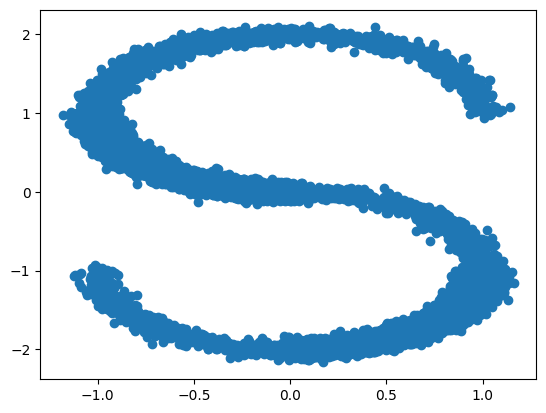

In [17]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, ax = plt.subplots()
ax.scatter(samples[:,0], samples[:, 1])
# ax.scatter(samples[:,0], samples[:, 1], c=adata.obs['leiden'].astype(int).tolist())
plt.show()

In [18]:
config = Config(
    {        
        "model_class": "metricflow",
        "score_max_epochs": 2000, # 2000
        "energy_max_epochs": 2000, # 2000
        "metric_max_epochs": 2,
        "embed_max_epochs": 2 if energy_only else 1000,
        "flow_max_epochs": 2 if energy_only else 2000,
        "lr": 1e-4,
        "dropout": 0.0,
        "pc_dim": d,
        "cond_dim": d,
        "hidden_dim": 256,
        "score_batch_size": 2048,
        "flow_batch_size": 256,
        "num_freq": 32,
        "num_layers": 4,
        "force_cpu": False,
        "gradient_clip_val": 0,
        "loader_batch_size": 6,
        "warmup_steps": 0,
        "ema_decay": 1-1e-3,

        "pita_steps": 3, #3


        "mfm_benchmark": False,
        "K": 500,
        "kappa": 1.0,

        "score_alpha": 1.0,

        "energy_noise_sigma": 0.0,
        "metric_scale": 3,
        "metric_sigma": 0.05,
        
        "ot_in_embed": True,
        "fast_ot": False,

        "num_sigmas": 20,
        "sigma_min": 0.05,
        "sigma_max": 0.2,

        "sigma_dim": 32,
        
        "score_beta_min": 1.0,
        "score_beta_max": 1.0,
        
        "latent_dim": 100,

        "skip": True,
        "rescale": 0.5,

        "pre_low_q": .05,
        "pre_high_q": .98,
        "low_q": .05,
        "high_q": .95,

        "weight_beta": 0.8,

        "gamma": 0.2,

        "sigma": 0.1,

        "n_neighbors": 10,
        "resolution": 0.3,
    }
)

project = "fm-ipynb"

In [19]:
# ### MFM BENCHMARK ###
# config.score_max_epochs = 2
# config.energy_max_epochs = 2
# config.metric_max_epochs = 1000
# config.mfm_benchmark = True
# config.K = 500
# config.kappa = 1.0
# config.pita_steps = 1

In [20]:
pre_score_models, pre_energy_models, score_model, energy_model, metric_model, embed_model, flow_model = run_full_model(config, project, adata, values, conditions, dataset)

/home/azweig/projects/zebrafish/datasets/process.py:82: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_train, resolution=resolution)


Running phase score:.......


wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type             | Params | Mode 
-----------------------------------------------------

score_pita


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type               | Params | Mode 
------------------------------------------------------------
0 | embed_net    | SimpleEmbedNet     | 238 K  | train
1 | geo_net      | SinNet             | 267 K  | train
2 | metric_model | MetricNetTrainBase | 340 K  | eval 
------------------------------------------------------------
505 K     Trainable params
340 K     Non-trainable params
845 K     Total params
3.384     Total estimated model params size (MB)
32 

epoch,▁▁▁▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇██
train_loss,██▄▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇████
epoch,999
train_loss,4569.41211
trainer/global_step,999


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | flow_net  | SinNet         | 254 K  | train
1 | geo_net   | SinNet         | 267 K  | eval 
2 | embed_net | SimpleEmbedNet | 238 K  | eval 
-----------------------------------------------------
521 K     Trainable params
238 K     Non-trainable params
760 K     Total params
3.040     Total estimated model params size (MB)
16        Modules in train mode
32        Mod

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▅▆▆▇▇▇▇▇████
train_loss,█▇█▇▅▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇███
epoch,1999
train_loss,0.21417
trainer/global_step,1999


In [21]:
def visualize(model, samples):

    import matplotlib.pyplot as plt
    plt.close('all')
    m = torch.max(torch.abs(samples)).item()
    m += 1
    
    xs = torch.linspace(-m, m, steps=30)
    ys = torch.linspace(-m, m, steps=30)
    x, y = torch.meshgrid(xs, ys, indexing='xy')
    print(x.shape)
    print(y.shape)
    z = torch.stack([x, y], dim = -1).reshape(900, -1)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    print(z.shape)
    
    v = model(z).detach()
    # h = torch.ones(z.shape[0],1).to(z.device) * min(model.score_sigma)
    # v = model(h, z).detach()

    fig, ax = plt.subplots()
    import numpy as np
    from scipy.stats import gaussian_kde
    # xy = samples.cpu().numpy().T
    # kde = gaussian_kde(xy)
    # grid = np.linspace(-m, m, 200)
    # xi, yi = np.meshgrid(grid, grid)
    # zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
    # ax.contour(xi, yi, zi, levels=10, linewidths=1)
    ax.scatter(samples[:,0], samples[:, 1])
    ax.quiver(z[:,0], z[:,1], v[:,0], v[:,1])
    plt.show()

In [22]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(score_model)
remove_all_forward_hooks(energy_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

torch.Size([30, 30])
torch.Size([30, 30])
torch.Size([900, 50])


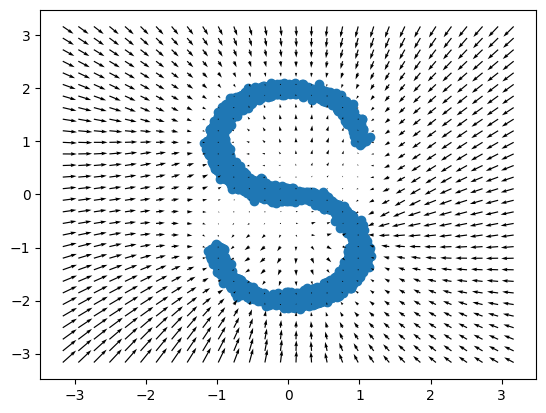

In [23]:
#SCORE VALIDATION
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize(score_model, samples)

In [24]:
def visualize_energy(energy_model, samples, grid_steps=30):

    import torch, numpy as np, matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    plt.close('all')

    m = torch.max(torch.abs(samples)).item() + 1.0
    xs = torch.linspace(-m,  m, steps=grid_steps)
    ys = torch.linspace(-m,  m, steps=grid_steps)
    xg, yg = torch.meshgrid(xs, ys, indexing='xy')
    z   = torch.stack([xg, yg], dim=-1).reshape(-1, 2)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    E = energy_model.get_energy(z).detach().reshape(grid_steps, grid_steps)

    fig, ax = plt.subplots()

    contour = ax.contourf(xg, yg, -E, levels=100, cmap='inferno')
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.005)
    ax.set_aspect('equal')
    fig.colorbar(contour, ax=ax, label="negative energy")
    plt.show()

In [25]:
def visualize_metric(metric_model, samples, grid_steps=30):

    import torch, numpy as np, matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    plt.close('all')

    m = torch.max(torch.abs(samples)).item() + 1.0
    xs = torch.linspace(-m,  m, steps=grid_steps)
    ys = torch.linspace(-m,  m, steps=grid_steps)
    xg, yg = torch.meshgrid(xs, ys, indexing='xy')
    z   = torch.stack([xg, yg], dim=-1).reshape(-1, 2)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    if config.mfm_benchmark:
        E = metric_model(z.to('cuda')).detach().reshape(grid_steps, grid_steps).cpu()
    else:
        E = metric_model(z).detach().reshape(grid_steps, grid_steps)

    fig, ax = plt.subplots()

    contour = ax.contourf(xg, yg, -E, levels=100, cmap='inferno')
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.005)
    ax.set_aspect('equal')
    fig.colorbar(contour, ax=ax, label="negative metric tensor")
    plt.show()

In [26]:
for sm in pre_score_models:
    print(sm.score_beta)

1.0
1.0
1.0


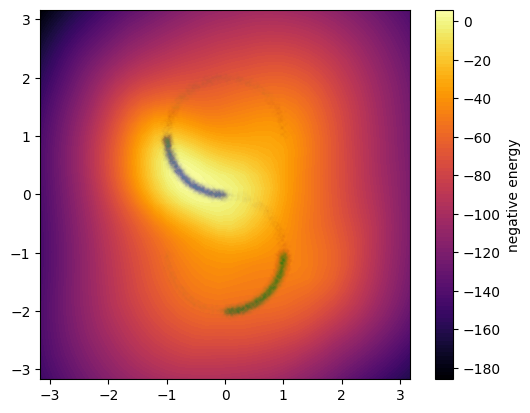

In [27]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_energy(pre_energy_models[0], samples)

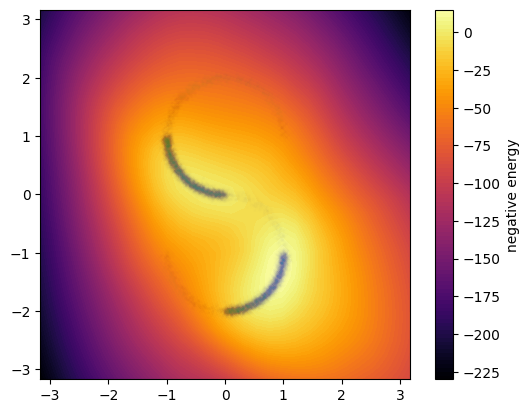

In [28]:
if len(pre_energy_models) > 1:
    samples = torch.from_numpy(adata.obsm['X_pca']).float()
    visualize_energy(pre_energy_models[1], samples)

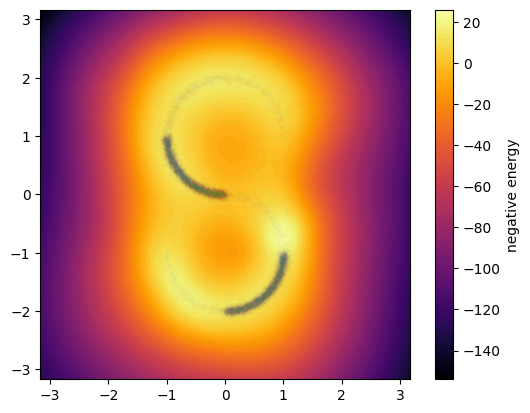

In [29]:
if len(pre_energy_models) > 2:
    samples = torch.from_numpy(adata.obsm['X_pca']).float()
    visualize_energy(pre_energy_models[2], samples)

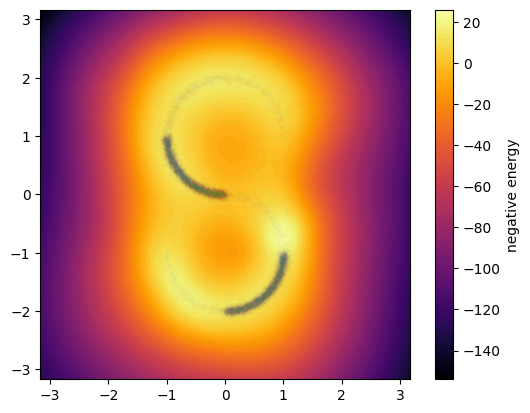

In [30]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_energy(energy_model, samples)

In [31]:
# _, score_dataset = extract_score_dataset(adata, values)
# train_dataset = TensorDataset(score_dataset)
# train_dataloader = DataLoader(train_dataset, batch_size = config.score_batch_size, shuffle=False) #need consistent order
# metric_model = build_metric(config, conditions, pre_energy_models[1])
# metric_model.low_quantile, metric_model.high_quantile = get_energy_statistics_global(pre_energy_models[1], train_dataloader,
#                                                                             low = config.low_q, high = config.high_q,
#                                                                              sigma=0.0)

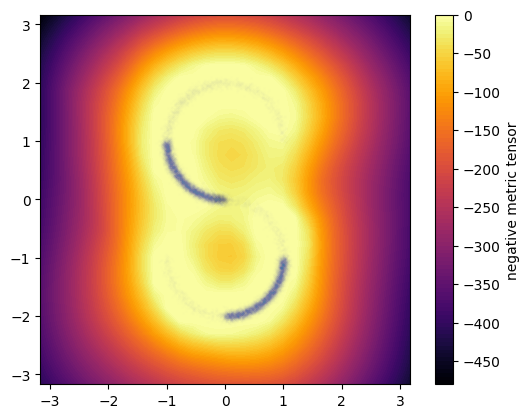

In [32]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_metric(metric_model, samples)

In [33]:
from torch.utils.data import TensorDataset, Sampler, DataLoader
from datasets.dataset import *

train_dataset = ShufflingDataset(dataset, 5, conditions)
train_dataloader = DataLoader(train_dataset, batch_size = config.loader_batch_size, shuffle=True)

In [34]:
#EMBED VALIDATION
#Only for G=1
# x0, x1, _, _, _= embed_model._prepare_batch(batch)
# x0, x1 = x0[0], x1[0]
# true_dist = torch.norm(x0 - x1, dim = -1)
# f = embed_model.embed_net
# learned_dist = torch.norm(f(x0).detach() - f(x1).detach(), dim=-1)
# print(torch.stack([true_dist, learned_dist], dim=1)[:10])

In [35]:
# for i in range(5):
#     traj = paths[:,i]

#     f_traj = embed_model.embed_net(traj).detach()
#     f_x0 = f_traj[0]
#     f_x1 = f_traj[-1]
#     learned_dist = torch.norm(f_x0 - f_x1)
    
#     x0 = traj[:-1]
#     x1 = traj[1:]
    
#     geo_dist = torch.sum(torch.sqrt(embed_model.squared_g_norm(x1 - x0, x0)))
#     print(learned_dist, geo_dist)

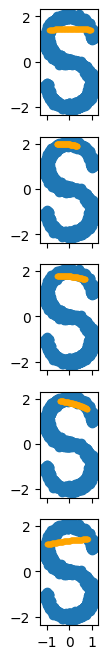

In [36]:
#GEO VALIDATION
if not energy_only:
    for batch in train_dataloader:
        
        paths = embed_model.sample_geodesic(batch, points=200, ot_sample=False)
        
        break
    
    fig, ax = plt.subplots(5, figsize=(8,8), sharex=True, sharey=True)
    for i in range(5):
        traj = paths[:,i]
        ax[i].scatter(samples[:,0], samples[:, 1])
        ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
        ax[i].set(adjustable='box', aspect='equal')
    plt.show()

In [37]:
#FLOW VALIDATION

num_samples = 100
steps = 500
value = 'ctrl-inj'
c = conditions[value]
c = c.unsqueeze(0).repeat(num_samples, 1)

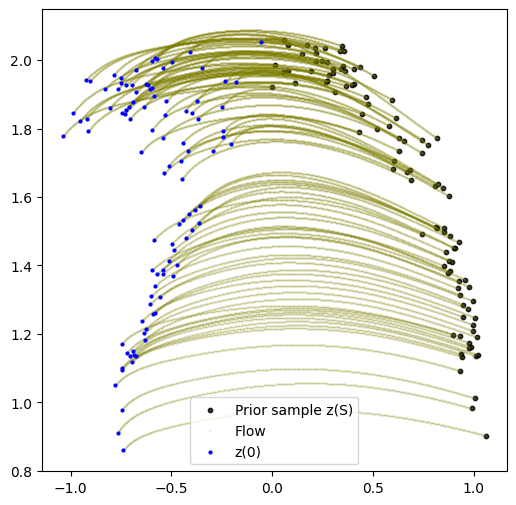

In [38]:
if not energy_only:
    t0 = 0
    t1 = 1
    x = fs[t0]()[:num_samples]
    traj = flow_model.sample_traj(x, c, t0, t1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

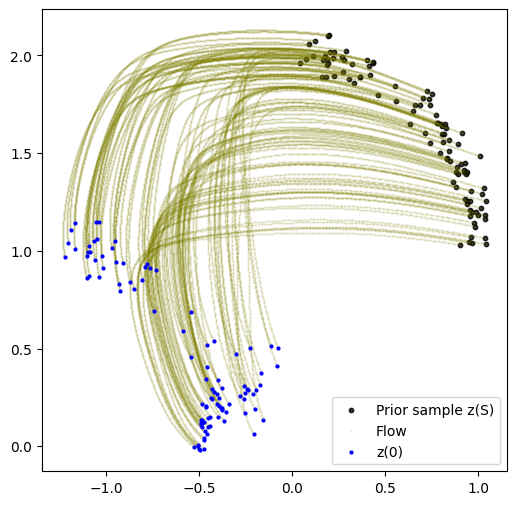

In [39]:
if not energy_only:
    t0 = 0
    t1 = 2
    x = fs[t0]()[:num_samples]
    traj = flow_model.sample_traj(x, c, t0, t1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

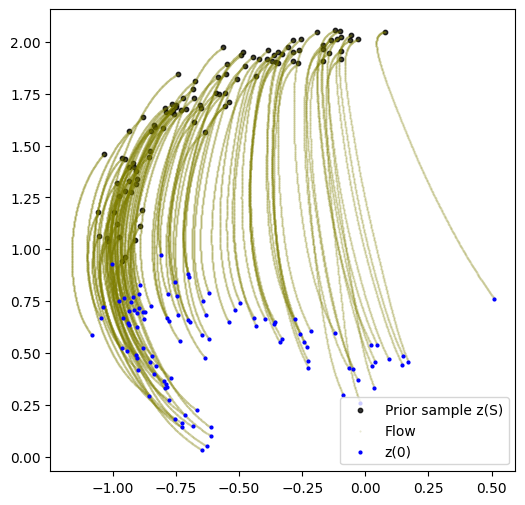

In [40]:
if not energy_only:
    t0 = 1
    t1 = 2
    x = fs[t0]()[:num_samples]
    traj = flow_model.sample_traj(x, c, t0, t1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

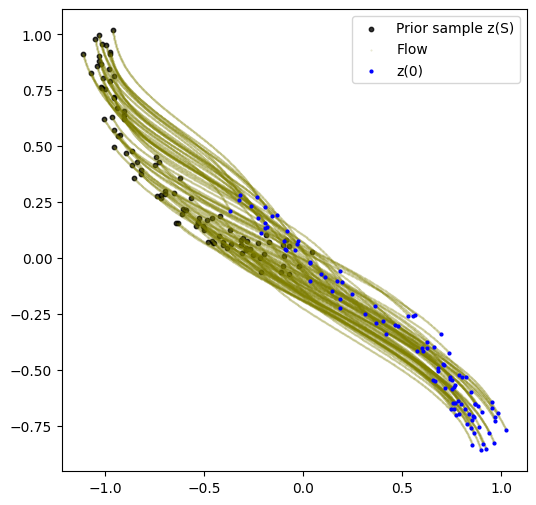

In [41]:
if not energy_only:
    t0 = 2
    t1 = 3
    x = fs[t0]()[:num_samples]
    traj = flow_model.sample_traj(x, c, t0, t1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

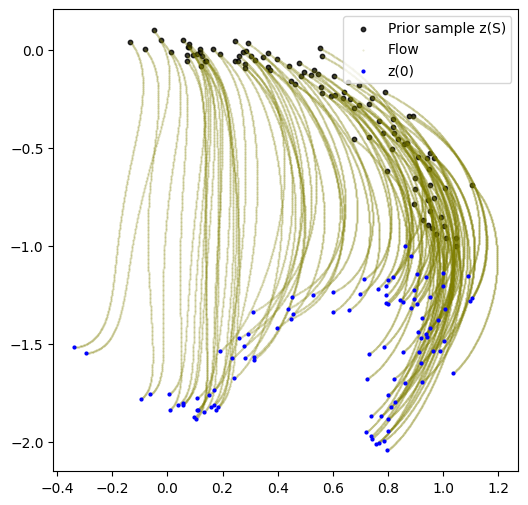

In [42]:
if not energy_only:
    t0 = 3
    t1 = 4
    x = fs[t0]()[:num_samples]
    traj = flow_model.sample_traj(x, c, t0, t1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

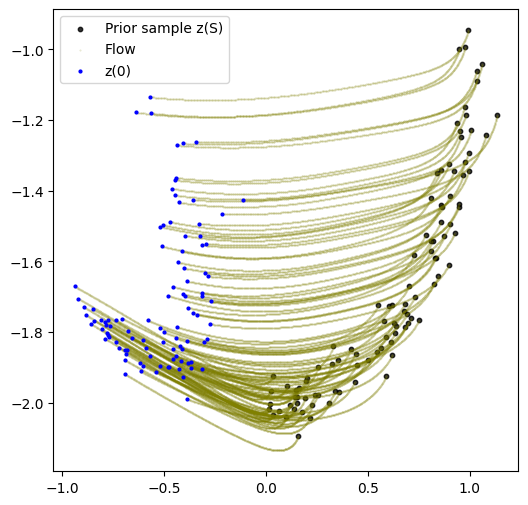

In [43]:
if not energy_only:
    t0 = 4
    t1 = 5
    x = fs[t0]()[:num_samples]
    traj = flow_model.sample_traj(x, c, t0, t1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

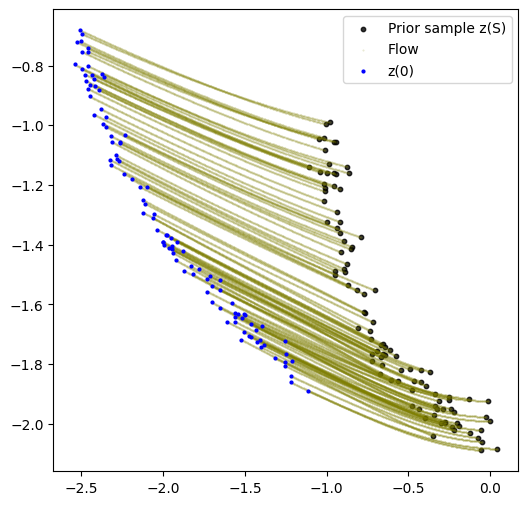

In [44]:
if not energy_only:
    t0 = 5
    t1 = 6
    x = fs[t0]()[:num_samples]
    traj = flow_model.sample_traj(x, c, t0, t1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

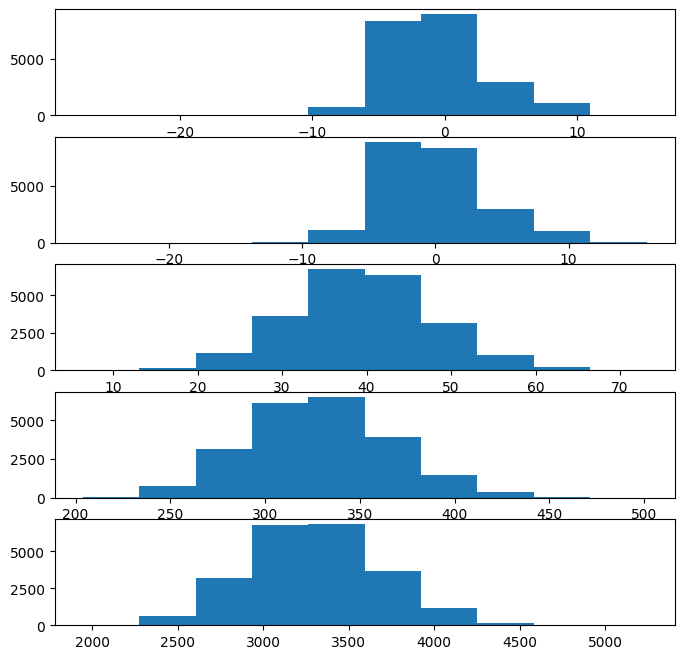

In [45]:
#HISTOGRAM of energy based on sampling distance from data
X = adata.obsm['X_pca']
X = torch.from_numpy(X).float()
sigmas = [0.0, 1e-2, 1e-1, 1e0, 1e1]
fig, axs = plt.subplots(len(sigmas), figsize=(8,8))
for i, sigma in enumerate(sigmas):
    noise = torch.randn_like(X)
    noise[:,:2] = 0. #check energy orthogonal to manifold
    # noise[:,2:] = 0. #check energy on manifold
    Z = X + sigma * noise
    Z = Z.to(energy_model.get_device())
    E = energy_model.get_energy(Z).detach().cpu().numpy()
    axs[i].hist(E)
plt.show()

In [46]:
#######